# 5.  Discover distribution parameter

1. Reproduce example presented during the lecture (anti-viral drug).

In [8]:
import arviz as az
import pymc as pm
import numpy as np
import matplotlib.pyplot as plt

In [2]:
occurrences = [1, 1, 1, 1, 1, 1, 1, 0, 0, 0]

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


Output()

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 40 seconds.


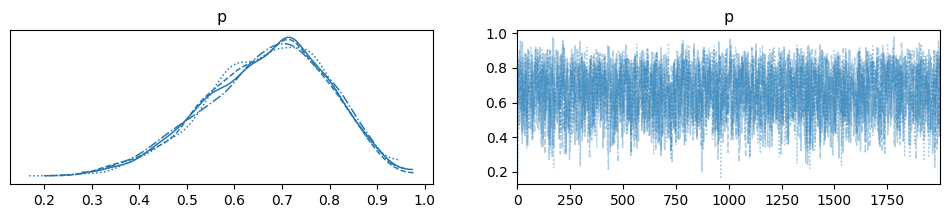

array([[<Axes: title={'center': 'p'}>, <Axes: title={'center': 'p'}>]],
      dtype=object)

In [3]:
with pm.Model() as model:
 p = pm.Uniform("p", lower=0, upper=1)
 obs = pm.Bernoulli("obs", p, observed=occurrences)
 idata = pm.sample(2000, tune=2500)
az.plot_trace(idata, show=True)

In [5]:
ones = np.ones(700)
zeros = np.zeros(300)
occurrences = np.concatenate((ones, zeros))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


Output()

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 209 seconds.


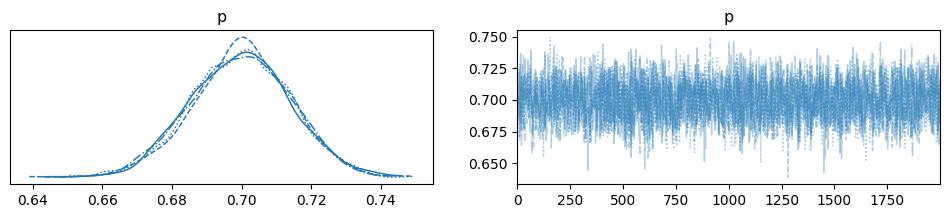

array([[<Axes: title={'center': 'p'}>, <Axes: title={'center': 'p'}>]],
      dtype=object)

In [6]:
with pm.Model() as model:
 p = pm.Uniform("p", lower=0, upper=1)
 obs = pm.Bernoulli("obs", p, observed=occurrences)
 idata = pm.sample(2000, tune=2500)
az.plot_trace(idata, show=True)

# 6. Compare distribution parameters

### a) 100 patients each, 70% vs 50% cured

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_treatment, p_control]
NUTS: [p_treatment, p_control]


Output()

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 48 seconds.


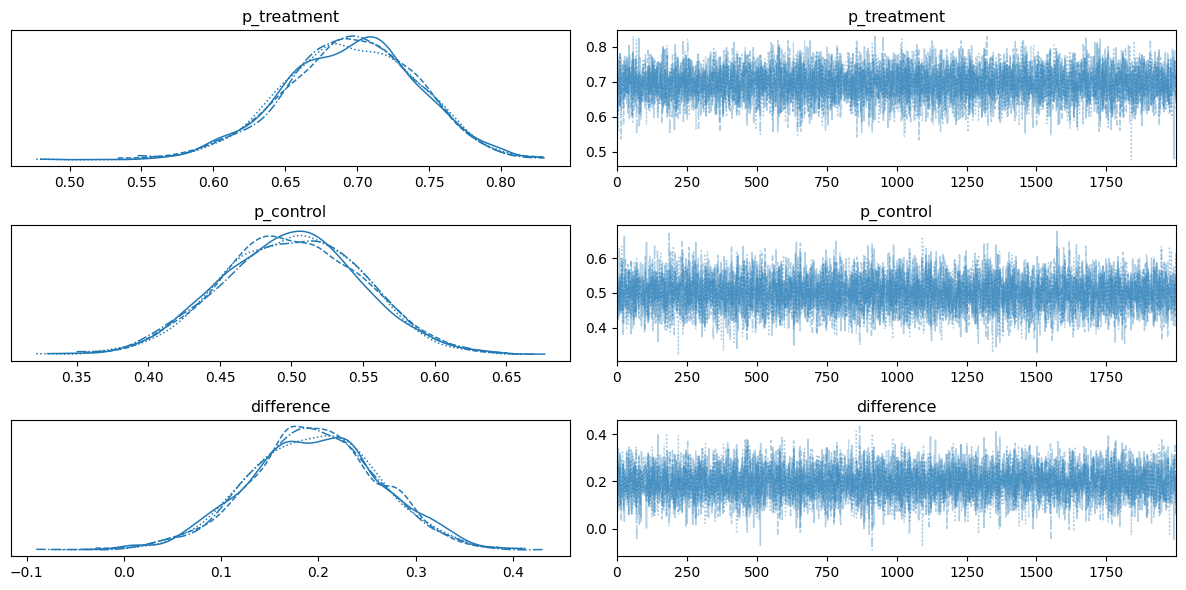

              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
p_treatment  0.696  0.046   0.608    0.780      0.001    0.001    8181.0   
p_control    0.500  0.049   0.408    0.591      0.001    0.001    8218.0   
difference   0.195  0.067   0.071    0.323      0.001    0.001    8150.0   

             ess_tail  r_hat  
p_treatment    5890.0    1.0  
p_control      6200.0    1.0  
difference     5960.0    1.0  


In [9]:
treatment_data = np.concatenate([np.ones(70), np.zeros(30)])

control_data = np.concatenate([np.ones(50), np.zeros(50)])

with pm.Model() as model_compare:
    p_treatment = pm.Uniform("p_treatment", lower=0, upper=1)
    p_control = pm.Uniform("p_control", lower=0, upper=1)
    
    obs_treatment = pm.Bernoulli("obs_treatment", p_treatment, observed=treatment_data)
    obs_control = pm.Bernoulli("obs_control", p_control, observed=control_data)
    
    # Deterministic variable to compare parameters
    diff = pm.Deterministic("difference", p_treatment - p_control)
    
    idata_compare = pm.sample(2000, tune=2500)

az.plot_trace(idata_compare, var_names=["p_treatment", "p_control", "difference"])
plt.tight_layout()
plt.show()

print(az.summary(idata_compare, var_names=["p_treatment", "p_control", "difference"]))

For 100 patients in each group (70% vs 50% cured), PyMC found that p_treatment is around 0.70 and p_control around 0.50. The left plots show the probability distributions - wider shape means more uncertainty. The right plots show the MCMC samples oscillating around these values, which is normal behavior. 

The difference is approximately 0.20 (20% better cure rate with treatment), but with some uncertainty due to the moderate sample size. We see 2000 samples after discarding the first 2500 tuning iterations.

### b) 1000 patients each, 70% vs 50% cured

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_treatment, p_control]
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_treatment, p_control]


Output()

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 463 seconds.


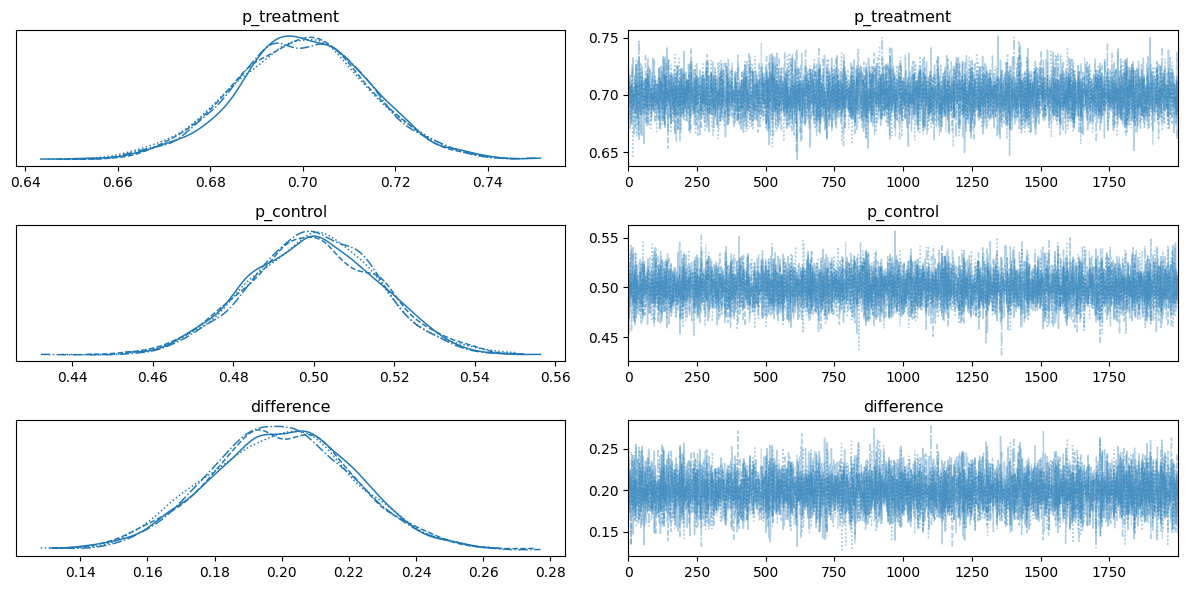

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
p_treatment   0.7  0.015   0.673    0.728        0.0      0.0    7759.0   
p_control     0.5  0.016   0.472    0.532        0.0      0.0    8498.0   
difference    0.2  0.021   0.160    0.240        0.0      0.0    8169.0   

             ess_tail  r_hat  
p_treatment    6495.0    1.0  
p_control      5922.0    1.0  
difference     6152.0    1.0  


In [10]:
treatment_data_b = np.concatenate([np.ones(700), np.zeros(300)])

control_data_b = np.concatenate([np.ones(500), np.zeros(500)])

with pm.Model() as model_compare_b:
    p_treatment = pm.Uniform("p_treatment", lower=0, upper=1)
    p_control = pm.Uniform("p_control", lower=0, upper=1)
    
    obs_treatment = pm.Bernoulli("obs_treatment", p_treatment, observed=treatment_data_b)
    obs_control = pm.Bernoulli("obs_control", p_control, observed=control_data_b)
    
    diff = pm.Deterministic("difference", p_treatment - p_control)
    
    idata_compare_b = pm.sample(2000, tune=2500)

az.plot_trace(idata_compare_b, var_names=["p_treatment", "p_control", "difference"])
plt.tight_layout()
plt.show()

print(az.summary(idata_compare_b, var_names=["p_treatment", "p_control", "difference"]))

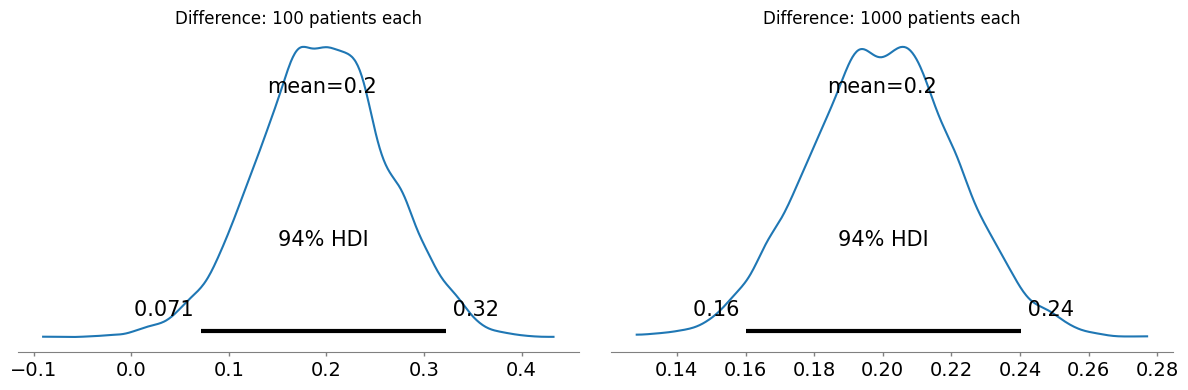

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

az.plot_posterior(idata_compare, var_names=["difference"], ax=axes[0])
axes[0].set_title("Difference: 100 patients each")

az.plot_posterior(idata_compare_b, var_names=["difference"], ax=axes[1])
axes[1].set_title("Difference: 1000 patients each")

plt.tight_layout()
plt.show()

With 1000 patients per group, the distributions become narrower - we're more certain about the results, as we can see on the second plot. Both parameters are tightly centered around 0.70 (treatment) and 0.50 (control). More data = more confidence in our estimates.

### c) Treatment: 10 patients (70%), Control: 1000 patients (50%)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_treatment, p_control]
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_treatment, p_control]


Output()

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 291 seconds.


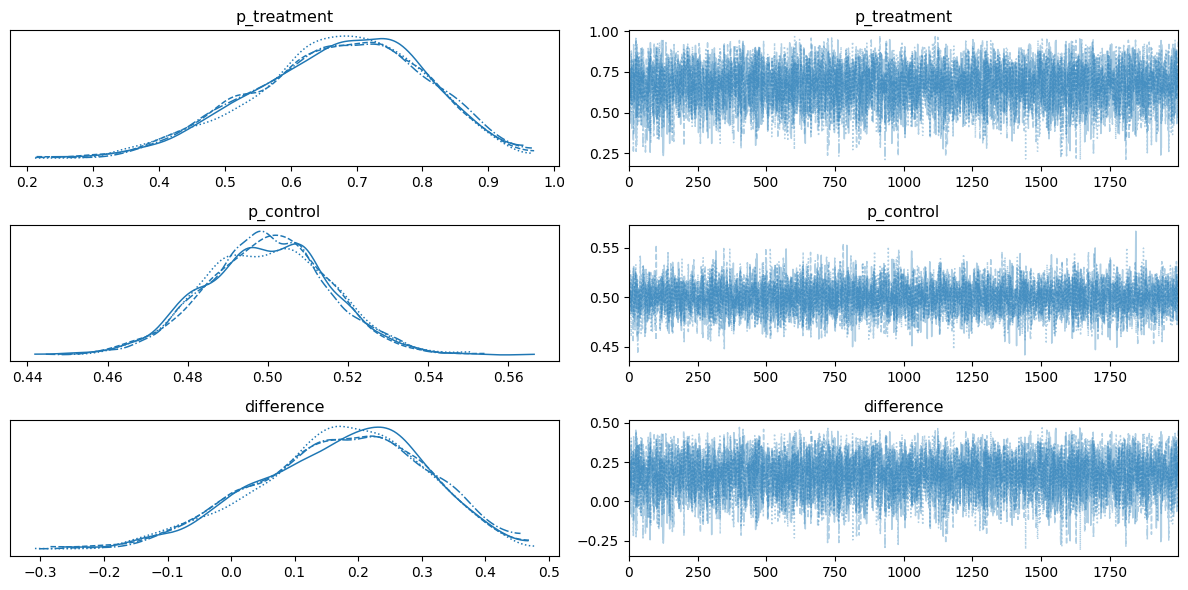

              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
p_treatment  0.669  0.131   0.423    0.899      0.002    0.001    7030.0   
p_control    0.500  0.016   0.472    0.530      0.000    0.000    7303.0   
difference   0.169  0.132  -0.075    0.406      0.002    0.001    7037.0   

             ess_tail  r_hat  
p_treatment    5671.0    1.0  
p_control      5557.0    1.0  
difference     5713.0    1.0  


In [11]:
treatment_data_c = np.concatenate([np.ones(7), np.zeros(3)])

control_data_c = np.concatenate([np.ones(500), np.zeros(500)])

with pm.Model() as model_compare_c:
    p_treatment = pm.Uniform("p_treatment", lower=0, upper=1)
    p_control = pm.Uniform("p_control", lower=0, upper=1)
    
    obs_treatment = pm.Bernoulli("obs_treatment", p_treatment, observed=treatment_data_c)
    obs_control = pm.Bernoulli("obs_control", p_control, observed=control_data_c)
    
    diff = pm.Deterministic("difference", p_treatment - p_control)
    
    idata_compare_c = pm.sample(2000, tune=2500)

az.plot_trace(idata_compare_c, var_names=["p_treatment", "p_control", "difference"])
plt.tight_layout()
plt.show()

print(az.summary(idata_compare_c, var_names=["p_treatment", "p_control", "difference"]))

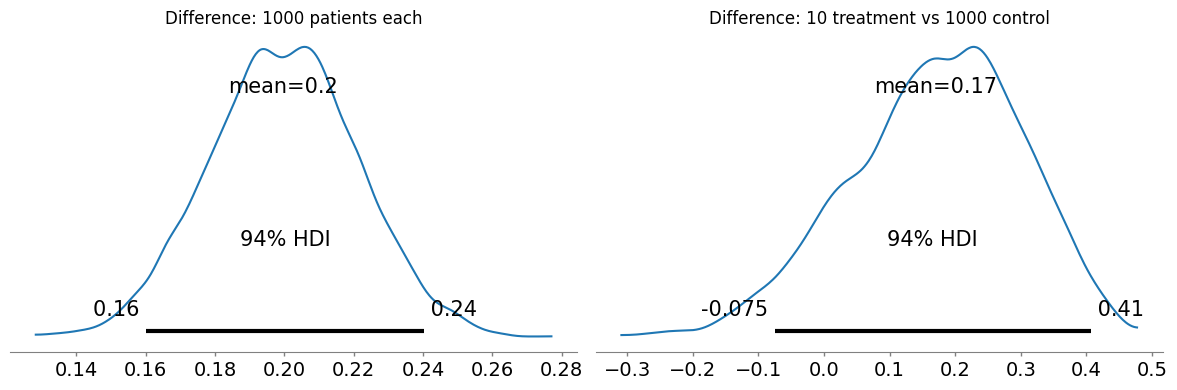

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

az.plot_posterior(idata_compare_b, var_names=["difference"], ax=axes[0])
axes[0].set_title("Difference: 1000 patients each")

az.plot_posterior(idata_compare_c, var_names=["difference"], ax=axes[1])
axes[1].set_title("Difference: 10 treatment vs 1000 control")

plt.tight_layout()
plt.show()

The control group (1000 patients) has a narrow, certain distribution around 0.50. But the treatment group (only 10 patients) has a very wide distribution - we can't be sure if p_treatment is 0.40, 0.70, or even 0.90. With so few patients, many values seem plausible. This makes the difference uncertain - we can't confidently say if treatment actually helps or not.